<h1 style="font-family: 'Georgia', serif; font-style: italic; color: #1B4F72;">
Sécurisation des Transactions Bancaires : Détection Automatisée de la Fraude sur Mobile

    Anti-Fraud AI : Détection des Transactions à Haut Risque
</h1>

In [2]:
#Financial Fraud Detection Synthetic Dataset
#About Dataset
#This dataset contains 10,000 synthetic financial transactions designed to support the development and testing of fraud detection machine learning models. Unlike generic datasets, this collection features engineered patterns where fraudulent behavior is highly correlated with specific conditions.

#Content
#The dataset includes the following features:

#Transaction_ID: Unique identifier for each transaction.
#Timestamp: The date and time of the transaction.
#Amount: Transaction value (ranging from 5.0 to 5000.0).
#Device: Device type used ('Mobile', 'Desktop', 'Tablet').
#Is_Fraud: Target label (0 for legitimate, 1 for fraudulent).
#Key Fraud Patterns

#This dataset is specifically designed with an embedded logic:

#High-Value Fraud: Fraudulent activities are significantly more frequent in transactions exceeding a specific threshold.
#Device Correlation: Fraudulent transactions exhibit a higher frequency when originated from 'Mobile' devices.

#Use Cases
#Binary Classification: Training models to detect fraudulent vs. legitimate transactions.
#Feature Importance Analysis: Evaluating how device type and transaction amount contribute to fraud identification.

In [9]:
#Le but est de créer un modèle d'intelligence artificielle capable de prédire si une transaction financière est frauduleuse ou non (Is_Fraud : 0 ou 1). C'est ce qu'on appelle un problème de classification binaire.

#Ce jeu de données a une particularité : il est "synthétique" et contient des règles logiques précises injectées volontairement :

#Le montant (Amount) : La fraude est très fréquente au-delà d'un certain montant.

#L'appareil (Device) : Les téléphones portables (Mobile) sont plus souvent associés à des fraudes.

#Le modèle va devoir détecter ces règles automatiquement pour bloquer les fraudeurs.

In [3]:
#Chargement des données
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv ('my_dataset.csv')
df.head()

,Transaction_ID,Amount,Device,Is_Fraud
0,b3b62399-3df5-4c83-b42f-01f03a5d0007,18.14,Tablet,0
1,70fd8b1f-ef2c-430e-a080-809ddf19c068,83.96,Tablet,0
2,00b962ee-e9ab-4ccb-9c96-132307ecb26d,6137.26,Mobile,1
3,0cb84537-b5bc-43b2-9dcb-3895c6386a9b,106.23,Tablet,0
4,739e81ac-255f-4dbe-8cc6-0a4c456fbb14,172.39,Desktop,0


In [8]:
# Etat des lieux des données
# taille du dataset (lignes,colonnes)
print("Forme du dataset:", df.shape)

#Types de colonnes et valeurs manquantes 
print("infos dur les données"), df.info()

#Proportion des fraudes ( 0 vs 1)
print("\Répartition des fraudes (0 = Normal, 1 = Fraude)")
print(df['Is_Fraud'].value_counts(normalize=True) * 100)


Forme du dataset: (10000, 4)
infos dur les données
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  10000 non-null  object 
 1   Amount          10000 non-null  float64
 2   Device          10000 non-null  object 
 3   Is_Fraud        10000 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 312.6+ KB
\Répartition des fraudes (0 = Normal, 1 = Fraude)
Is_Fraud
0    95.1
1     4.9
Name: proportion, dtype: float64


In [22]:
# Pour réaliser ce projet, nous allons suivre les étapes suivantes: 

# 1. EDA (Exploration et visualisation des données)

# 2. Pre-processing (Nettoyage et encodage numérique des textes)

# 3. Modélisation (Entraînement d'une Forêt Aléatoire)

# 4. Évaluation (Analyse fine des matrices de confusion et des scores de classification)

# 5. Interprétabilité (Compréhension des choix du modèle)

<h1 style="font-family: 'Courier New', monospace; color: #2E4053;">
   1. EDA (Exploration et visualisation des données)
</h1>

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_13088\2408241022.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Is_Fraud', y='Amount', data=df, palette='Set2')
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_13088\2408241022.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal (0)', 'Fraude (1)'])
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_13088\2408241022.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Device', y='Is_Fraud', data=df, palette='pastel', errorbar=None)


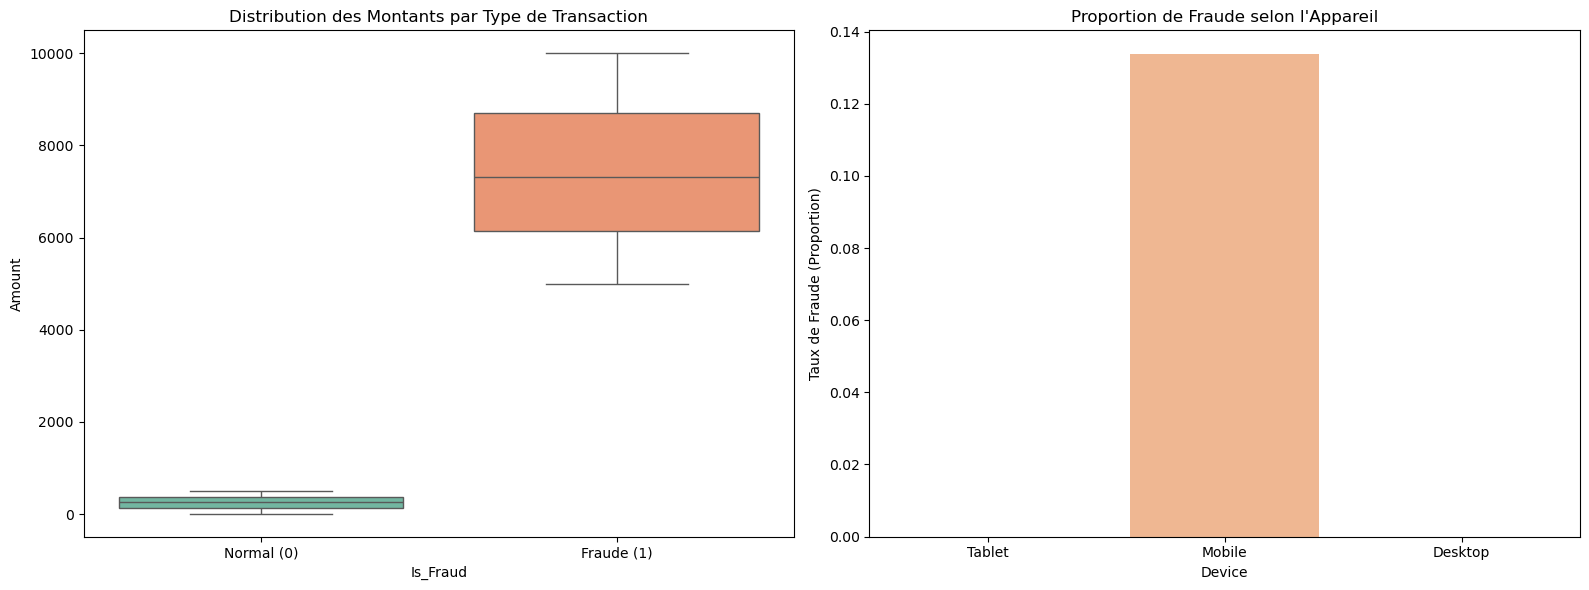

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créer une figure avec deux graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Distribution des montants selon la fraude
sns.boxplot(ax=axes[0], x='Is_Fraud', y='Amount', data=df, palette='Set2')
axes[0].set_title('Distribution des Montants par Type de Transaction')
axes[0].set_xticklabels(['Normal (0)', 'Fraude (1)'])

# Graphique 2 : Taux de fraude par type d'appareil
sns.barplot(ax=axes[1], x='Device', y='Is_Fraud', data=df, palette='pastel', errorbar=None)
axes[1].set_title("Proportion de Fraude selon l'Appareil")
axes[1].set_ylabel('Taux de Fraude (Proportion)')

plt.tight_layout()
plt.show()

In [1]:
# Graphique 1 : Distribution des montants selon la fraude : On voit clairement que presque toutes les transactions normales sont concentrées en bas 
#(généralement en dessous de 1 000 ou 2 000 ), tandis que la fraude s'envole sur de très gros montants.

# Graphique 2 : Taux de fraude par type d'appareil : Le taux de fraude sur Mobile est nettement supérieur aux autres supports.

<h1 style="font-family: 'Courier New', monospace; color: #2E4053;">
   2. Pre-processing (Nettoyage et encodage numérique des textes
</h1>

In [4]:
# Nous allons préparer ces données pour que le modèle de Machine Learning puisse les lire
# 1. On supprime la colonne Transaction_ID qui ne sert à rien pour prédire
df_cleaned = df.drop(columns=['Transaction_ID'])

# 2. On transforme la variable textuelle 'Device' en chiffres (One-Hot Encoding)
# Cela va créer des colonnes Device_Mobile, Device_Desktop, Device_Tablet avec des 0 et des 1
df_encoded = pd.get_dummies(df_cleaned, columns=['Device'], drop_first=False)

# 3. On sépare les variables explicatives (X) et la variable à prédire (y)
X = df_encoded.drop(columns=['Is_Fraud'])
y = df_encoded['Is_Fraud']

# 4. On divise le dataset : 80% pour l'entraînement et 20% pour le test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Entraînement (lignes, colonnes) :", X_train.shape)
print("Test (lignes, colonnes) :", X_test.shape)

Entraînement (lignes, colonnes) : (8000, 4)
Test (lignes, colonnes) : (2000, 4)


In [5]:
# pd.get_dummies : Convertit le texte en format numérique. C'est indispensable 
# car les algorithmes mathématiques ne savent pas calculer avec le mot "Mobile".

# train_test_split : Il garde 20% des données (2 000 transactions) secrètes dans un coin (X_test et y_test). 
# Le modèle va s'entraîner uniquement sur les 80% restants. 
# À la fin, on testera le modèle sur ces données secrètes pour voir s'il est vraiment performant.

# stratify=y : C'est une option très importante ici ! Comme on a seulement 4,9% de fraude, 
# cela force Python à mettre exactement 4,9% de fraude dans le groupe d'entraînement et 4,9% dans le groupe de test.

<h1 style="font-family: 'Courier New', monospace; color: #2E4053;">
   3. Modélisation (Entraînement d'une Forêt Aléatoire)
</h1>

In [6]:
# L'entraînement du modèle.

#Pour ce type de problème basé sur des seuils de montants et des catégories d'appareils, 
# l'un des meilleurs algorithmes est la Forêt Aléatoire (Random Forest). 
# Imaginons que c'est un ensemble d'arbres de décision qui vont voter pour déterminer si une transaction est une fraude ou non.

In [7]:
from sklearn.ensemble import RandomForestClassifier

# 1. On crée une instance du modèle
# class_weight='balanced' aide le modèle à faire attention à la fraude même si elle est rare
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. On entraîne le modèle sur les données d'entraînement
model.fit(X_train, y_train)

print("Entraînement réussi !")

Entraînement réussi !


<h1 style="font-family: 'Courier New', monospace; color: #2E4053;">
   4. Évaluation (Analyse fine des matrices de confusion et des scores de classification)
</h1>

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1902
           1       1.00      1.00      1.00        98

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

--- Matrice de Confusion ---


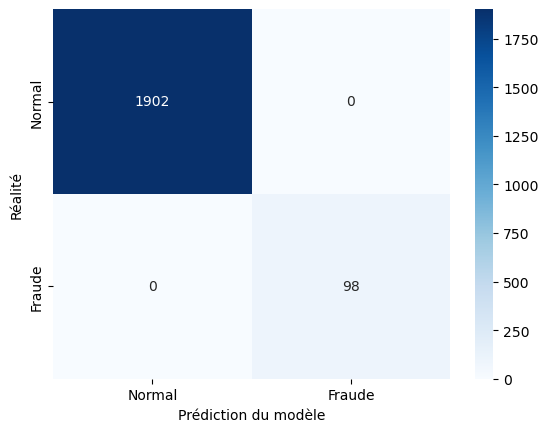

In [9]:
# L'évaluation du modèle
from sklearn.metrics import classification_report, confusion_matrix

# 3. Le modèle prédit sur les données de test qu'il n'a jamais vues
y_pred = model.predict(X_test)

# 4. On affiche les résultats détaillés
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# 5. On affiche la matrice de confusion
print("--- Matrice de Confusion ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
plt.ylabel('Réalité')
plt.xlabel('Prédiction du modèle')
plt.show()

In [10]:
# Recall (Rappel) : C'est le pourcentage de fraudes réelles que ton modèle a réussi à bloquer. 
# S'il est proche de 1.00 (100%), le modèle est un excellent détective.

# Precision : C'est la capacité du modèle à ne pas se tromper. Si la précision est haute, 
# cela veut dire qu'il ne bloque pas de clients honnêtes par erreur.

# Sur la Matrice de Confusion graphique :

# La case en bas à droite montre les fraudes correctement attrapées.
# La case en haut à droite montre les clients normaux bloqués à tort (les "Faux Positifs").

# Precision = 1.00 : Cela signifie que chaque fois que le modèle a suspecté une fraude, 
# il a eu raison à 100 %. Il n'y a aucun faux positif (0 client honnête bloqué par erreur).

# Recall = 1.00 : Le modèle a attrapé 100 % des fraudes présentes dans le jeu de test. 
# La matrice de confusion le confirme : les 98 fraudes réelles ont toutes été détectées (case en bas à droite)

# Le modèle a parfaitement craqué le code et la logique injectée dans ce dataset synthétique.

<h1 style="font-family: 'Courier New', monospace; color: #2E4053;">
5. Interprétabilité (Compréhension des choix du modèle)
</h1>

In [40]:
# L'Analyse de l'Importance des Variables 
# Pour clore ce projet, on va demander mathématiquement au modèle quelles fonctionnalités ont guidé ses choix. 
# Cela me permettra de prouver que l'IA a bien découvert les deux règles de l'énoncé (Amount et Device).

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_6808\1665593290.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')


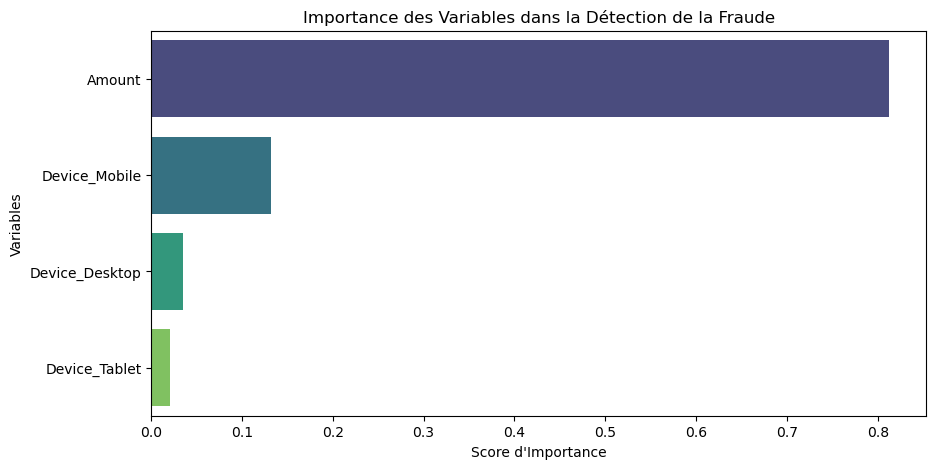

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Récupérer l'importance des variables calculée par la Forêt Aléatoire
importances = model.feature_importances_
features = X.columns

# 2. Créer un DataFrame pour faciliter l'affichage
df_importance = pd.DataFrame({'Variable': features, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 3. Afficher le graphique
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')
plt.title("Importance des Variables dans la Détection de la Fraude")
plt.xlabel("Score d'Importance")
plt.ylabel("Variables")
plt.show()

In [13]:
# Ce dernier graphique confirme exactement ce que l'on suspectait : le montant (Amount) est le facteur décisif absolu pour le modèle 
# (avec un score d'importance écrasant d'environ plus de 0,8), 
# suivi de très loin par le fait que la transaction provienne d'un appareil mobile (Device_Mobile).

# Cela montre que l'arbre de décision s'est dit : "Je regarde d'abord si le montant dépasse un certain seuil. 
# Si c'est le cas et que c'est sur Mobile, c'est une fraude"

In [14]:
#  On sauvegarde ce travail pour pouvoir réutiliser le modèle d'IA plus tard dans un autre script (ou une application web) sans avoir à le réentraîner, 
#  on peux l'exporter dans un fichier.

In [15]:
import joblib

# Sauvegarder le modèle entraîné dans un fichier
joblib.dump(model, 'modèle_fraude_finance.pkl')
print("Modèle sauvegardé avec succès sous le nom 'modèle_fraude_finance.pkl' !")

Modèle sauvegardé avec succès sous le nom 'modèle_fraude_finance.pkl' !


In [20]:
# Pour le réutiliser un jour, il suffira de faire 
# mon_modele = joblib.load('modèle_fraude_finance.pkl').